# VIA I–V analysis

This template detects the sustained current-compliance plateau, excludes only that plateau, and fits every lower-current point to $I = GV + I_0$, with $R = 1/G$. The reported uncertainty is the regression standard error; it does not include instrument or other systematic uncertainties.

The functions below do not save or export files. They only return data, fit results, and a Matplotlib figure in memory. Set `FILE_NAME` and `CURVE_LABEL` in the **Select a data file** cell, then run the notebook.

In [4]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path(
    r"/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/"
    r"Other computers/USB and External Devices/KINGSTON/Electrical_Gen3/"
    r"VIA_DATA/D2/full_vias"
)

## Select a data file

Change only `FILE_NAME` and `CURVE_LABEL`, then run the cells below.

In [5]:
FILE_NAME = "probe.txt"       # File inside DATA_DIR
CURVE_LABEL = "Probe"         # X in: Measured IV Curve: X

FILE_PATH = DATA_DIR / FILE_NAME

In [6]:
def load_iv(path, voltage_column="VA", current_column="IA"):
    """Load a headered I–V text file and return finite voltage/current arrays."""
    path = Path(path)
    data = np.genfromtxt(
        path, names=True, comments="#", autostrip=True, encoding=None
    )
    if data.dtype.names is None:
        raise ValueError(f"No headered columns found in {path}")

    names = {name.lower(): name for name in data.dtype.names}
    try:
        v_name = names[voltage_column.lower()]
        i_name = names[current_column.lower()]
    except KeyError as error:
        raise ValueError(
            f"Expected columns {voltage_column!r} and {current_column!r}; "
            f"found {data.dtype.names}"
        ) from error

    voltage = np.atleast_1d(np.asarray(data[v_name], dtype=float))
    current = np.atleast_1d(np.asarray(data[i_name], dtype=float))
    finite = np.isfinite(voltage) & np.isfinite(current)
    return voltage[finite], current[finite]


def detect_compliance_start(
    current, flat_run=3, flat_relative_tolerance=1e-4, minimum_level_fraction=0.5
):
    """Return the index where a sustained, high-current plateau begins."""
    current = np.asarray(current, dtype=float)
    max_abs_current = float(np.max(np.abs(current)))
    if max_abs_current == 0 or current.size < flat_run + 2:
        return None

    tolerance = max(
        flat_relative_tolerance * max_abs_current, 10 * np.finfo(float).eps
    )
    flat_steps = np.abs(np.diff(current)) <= tolerance
    for start in range(len(flat_steps) - flat_run + 1):
        if np.all(flat_steps[start : start + flat_run]):
            plateau = current[start : start + flat_run + 1]
            if np.median(np.abs(plateau)) >= minimum_level_fraction * max_abs_current:
                return start
    return None


def fit_pre_compliance(voltage, current, minimum_points=3):
    """Fit every acquired point before compliance; exclude nothing else."""
    voltage = np.asarray(voltage, dtype=float)
    current = np.asarray(current, dtype=float)
    plateau_start = detect_compliance_start(current)
    fit_stop = plateau_start if plateau_start is not None else len(voltage)
    fit_mask = np.arange(len(voltage)) < fit_stop

    if np.count_nonzero(fit_mask) < minimum_points:
        raise ValueError("Too few pre-compliance points for a linear fit")

    fit_v = voltage[fit_mask]
    fit_i = current[fit_mask]
    (conductance, intercept), covariance = np.polyfit(fit_v, fit_i, 1, cov=True)
    prediction = conductance * fit_v + intercept
    residual = fit_i - prediction
    residual_sum = float(np.sum(residual**2))
    total_sum = float(np.sum((fit_i - np.mean(fit_i)) ** 2))
    r_squared = 1 - residual_sum / total_sum
    conductance_se = math.sqrt(float(covariance[0, 0]))
    resistance = 1 / conductance
    resistance_se = abs(conductance_se / conductance**2)

    result = {
        "resistance_ohm": float(resistance),
        "resistance_se_ohm": float(resistance_se),
        "conductance_s": float(conductance),
        "current_intercept_a": float(intercept),
        "r_squared": r_squared,
        "rmse_a": math.sqrt(residual_sum / len(fit_v)),
        "fit_min_v": float(np.min(fit_v)),
        "fit_max_v": float(np.max(fit_v)),
        "points_fit": int(np.count_nonzero(fit_mask)),
        "plateau_start_index": plateau_start,
        "plateau_start_v": (
            float(voltage[plateau_start]) if plateau_start is not None else np.nan
        ),
        "compliance_current_a": (
            float(np.median(current[plateau_start:]))
            if plateau_start is not None
            else np.nan
        ),
    }
    return fit_mask, result


def set_publication_style():
    plt.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": 18,
            "mathtext.fontset": "custom",
            "mathtext.rm": "Arial",
            "mathtext.it": "Arial:italic",
            "mathtext.bf": "Arial:bold",
            "axes.labelsize": 18,
            "axes.titlesize": 18,
            "axes.linewidth": 1.3,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 6,
            "ytick.major.size": 6,
            "xtick.major.width": 1.3,
            "ytick.major.width": 1.3,
            "legend.fontsize": 15,
            "lines.linewidth": 2.2,
            "svg.fonttype": "none",
            "pdf.fonttype": 42,
        }
    )


def plot_iv(voltage, current, fit_mask, fit, curve_label):
    """Build the publication-style figure in memory; do not save it."""
    set_publication_style()
    current_ma = 1e3 * current
    fit_v = voltage[fit_mask]
    fit_i_ma = 1e3 * current[fit_mask]
    line_v = np.linspace(fit_v.min(), fit_v.max(), 250)
    line_i_ma = 1e3 * (
        fit["conductance_s"] * line_v + fit["current_intercept_a"]
    )

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.5), constrained_layout=True)
    data_color = "#1f4e79"
    fit_color = "#b22222"

    axes[0].plot(
        voltage, current_ma, "o-", color=data_color, markersize=4.8,
        markeredgewidth=0, label="Measured"
    )
    axes[0].set_title(f"Measured IV Curve: {curve_label}")
    axes[0].set_xlabel("Voltage (V)")
    axes[0].set_ylabel("Current (mA)")
    axes[0].legend(frameon=False, loc="lower right")

    axes[1].plot(
        fit_v, fit_i_ma, "o", color=data_color, markersize=6.5,
        label="All pre-compliance data"
    )
    axes[1].plot(line_v, line_i_ma, color=fit_color, label="Linear fit")
    axes[1].set_title("Pre-compliance Fit")
    axes[1].set_xlabel("Voltage (V)")
    axes[1].set_ylabel("Current (mA)")
    axes[1].legend(frameon=False, loc="lower right")
    axes[1].text(
        0.05, 0.95,
        f'$R$ = {fit["resistance_ohm"]:.4g} ± '
        f'{fit["resistance_se_ohm"]:.2g} Ω\n'
        f'$R^2$ = {fit["r_squared"]:.5f}\n'
        f'Fit: {fit["fit_min_v"]:g}–{fit["fit_max_v"]:g} V',
        transform=axes[1].transAxes, va="top", fontsize=16,
    )

    for panel_label, axis in zip(("(a)", "(b)"), axes):
        axis.text(
            -0.16, 1.05, panel_label, transform=axis.transAxes, fontweight="bold"
        )
        axis.tick_params(top=True, right=True)
        axis.margins(x=0.04, y=0.08)

    return fig, axes


def analyze_iv(path, curve_label=None, voltage_column="VA", current_column="IA"):
    """Load, fit, and plot one trace without writing anything to disk."""
    voltage, current = load_iv(path, voltage_column, current_column)
    fit_mask, fit = fit_pre_compliance(voltage, current)
    if curve_label is None:
        curve_label = Path(path).stem
    fig, axes = plot_iv(voltage, current, fit_mask, fit, curve_label)
    return {
        "voltage_v": voltage,
        "current_a": current,
        "fit_mask": fit_mask,
        "fit": fit,
        "figure": fig,
        "axes": axes,
    }

{'resistance_ohm': 1.234218649673113,
 'resistance_se_ohm': 0.02149860711167562,
 'conductance_s': 0.8102292087912085,
 'current_intercept_a': -0.0006302285714285621,
 'r_squared': 0.9966735419448888,
 'rmse_a': 0.0008757022764608109,
 'fit_min_v': 0.0,
 'fit_max_v': 0.06,
 'points_fit': 13,
 'plateau_start_index': 13,
 'plateau_start_v': 0.065,
 'compliance_current_a': 0.050081}

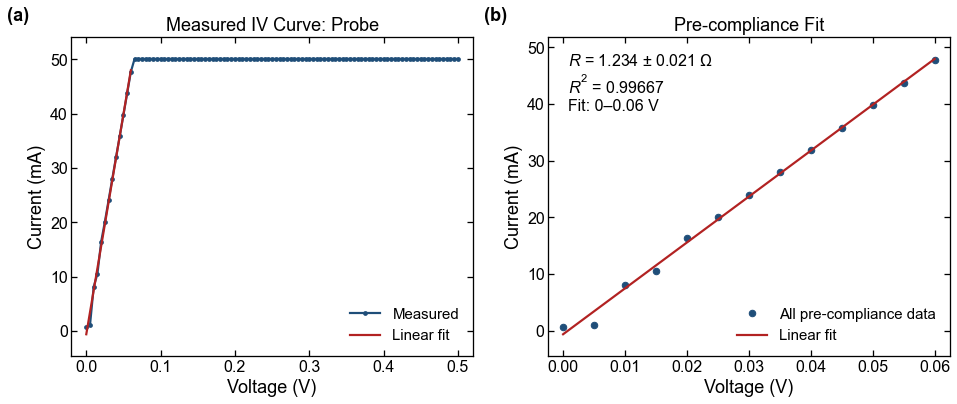

In [7]:
iv_analysis = analyze_iv(FILE_PATH, curve_label=CURVE_LABEL)
iv_analysis["fit"]

{'resistance_ohm': 2.6573783409122638,
 'resistance_se_ohm': 0.013031937284570928,
 'conductance_s': 0.3763107362637363,
 'current_intercept_a': 9.794142857143457e-05,
 'r_squared': 0.999711485856089,
 'rmse_a': 0.00025770301824282047,
 'fit_min_v': 0.0,
 'fit_max_v': 0.13,
 'points_fit': 14,
 'plateau_start_index': 14,
 'plateau_start_v': 0.14,
 'compliance_current_a': 0.050085}

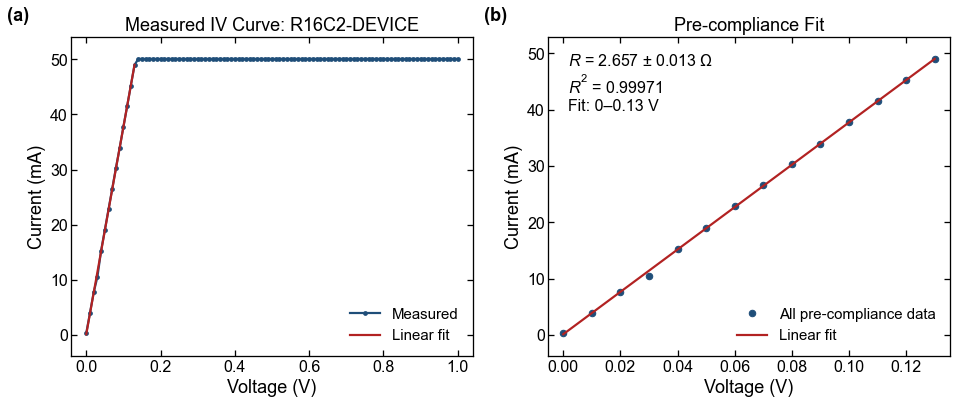

In [18]:
# Analyze and visualize a second file
SECOND_FILE_NAME = "R17C3_dev.txt"
SECOND_CURVE_LABEL = "R16C2-DEVICE"

second_iv_analysis = analyze_iv(
    DATA_DIR / SECOND_FILE_NAME,
    curve_label=SECOND_CURVE_LABEL,
)
second_iv_analysis["fit"]

## Repeated-probe comparison

Choose one subfolder below. The cell overlays all three measurements and fits only the second and third pre-compliance regions.

{'Second': {'resistance_ohm': 10.36143675608211,
  'resistance_se_ohm': 0.5680236668709995,
  'conductance_s': 0.09651171198945988,
  'current_intercept_a': 0.0048328562512077325,
  'r_squared': 0.8855596501525018,
  'rmse_a': 0.004505835464464487,
  'fit_min_v': 0.0,
  'fit_max_v': 0.44,
  'points_fit': 45,
  'plateau_start_index': 45,
  'plateau_start_v': 0.45,
  'compliance_current_a': 0.050076},
 'Third': {'resistance_ohm': 8.344810264888828,
  'resistance_se_ohm': 0.12261674031991047,
  'conductance_s': 0.1198349594846447,
  'current_intercept_a': 0.0026583059246954653,
  'r_squared': 0.9914376691150897,
  'rmse_a': 0.00134984021315178,
  'fit_min_v': 0.0,
  'fit_max_v': 0.41,
  'points_fit': 42,
  'plateau_start_index': 42,
  'plateau_start_v': 0.42,
  'compliance_current_a': 0.050076}}

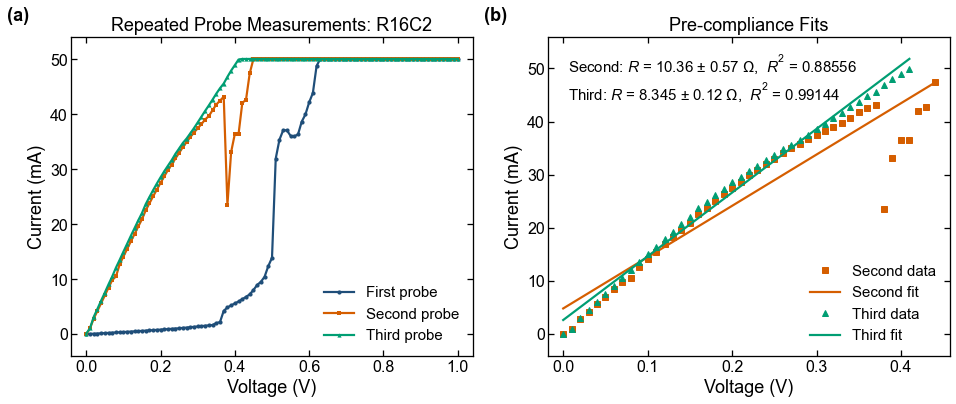

In [16]:
# ---------- User input ----------
REPEAT_FOLDER = "R16C2"       # Also available: R10C4 or R16C2
REPEAT_LABEL = "R16C2"
# --------------------------------

repeat_dir = DATA_DIR / REPEAT_FOLDER
repeat_files = {
    "First": repeat_dir / "first_time.txt",
    "Second": repeat_dir / "second_time.txt",
    "Third": repeat_dir / "third_time.txt",
}

# Load all three traces.
repeat_data = {}
for repeat_name, path in repeat_files.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing {repeat_name.lower()} measurement: {path}")
    repeat_data[repeat_name] = load_iv(path)

# Fit only the second and third traces, excluding only their plateaus.
repeated_probe_fits = {}
for repeat_name in ("Second", "Third"):
    voltage, current = repeat_data[repeat_name]
    fit_mask, fit = fit_pre_compliance(voltage, current)
    repeated_probe_fits[repeat_name] = {"fit_mask": fit_mask, **fit}

# Publication-style overlay and fit comparison; nothing is saved to disk.
set_publication_style()
fig_repeats, axes_repeats = plt.subplots(
    1, 2, figsize=(13.2, 5.5), constrained_layout=True
)
colors = {"First": "#1f4e79", "Second": "#d55e00", "Third": "#009e73"}
markers = {"First": "o", "Second": "s", "Third": "^"}

for repeat_name in ("First", "Second", "Third"):
    voltage, current = repeat_data[repeat_name]
    axes_repeats[0].plot(
        voltage, 1e3 * current,
        color=colors[repeat_name], marker=markers[repeat_name],
        markersize=4.2, markeredgewidth=0, label=f"{repeat_name} probe",
    )

for repeat_name in ("Second", "Third"):
    voltage, current = repeat_data[repeat_name]
    fit = repeated_probe_fits[repeat_name]
    fit_mask = fit["fit_mask"]
    fit_v = voltage[fit_mask]
    fit_i_ma = 1e3 * current[fit_mask]
    line_v = np.linspace(fit_v.min(), fit_v.max(), 250)
    line_i_ma = 1e3 * (
        fit["conductance_s"] * line_v + fit["current_intercept_a"]
    )
    axes_repeats[1].plot(
        fit_v, fit_i_ma, linestyle="none", marker=markers[repeat_name],
        markersize=5.5, color=colors[repeat_name], label=f"{repeat_name} data",
    )
    axes_repeats[1].plot(
        line_v, line_i_ma, color=colors[repeat_name],
        label=f"{repeat_name} fit",
    )

axes_repeats[0].set_title(f"Repeated Probe Measurements: {REPEAT_LABEL}")
axes_repeats[1].set_title("Pre-compliance Fits")
for axis in axes_repeats:
    axis.set_xlabel("Voltage (V)")
    axis.set_ylabel("Current (mA)")
    axis.legend(frameon=False, loc="lower right")
    axis.tick_params(top=True, right=True)
    axis.margins(x=0.04, y=0.08)

fit_text = []
for repeat_name in ("Second", "Third"):
    fit = repeated_probe_fits[repeat_name]
    fit_text.append(
        f'{repeat_name}: $R$ = {fit["resistance_ohm"]:.4g} ± '
        f'{fit["resistance_se_ohm"]:.2g} Ω,  '
        f'$R^2$ = {fit["r_squared"]:.5f}'
    )
axes_repeats[1].text(
    0.05, 0.95, "\n".join(fit_text),
    transform=axes_repeats[1].transAxes, va="top", fontsize=15,
)
for panel_label, axis in zip(("(a)", "(b)"), axes_repeats):
    axis.text(
        -0.16, 1.05, panel_label, transform=axis.transAxes, fontweight="bold"
    )

# Display the numerical second/third fit results below the figure.
{
    name: {key: value for key, value in fit.items() if key != "fit_mask"}
    for name, fit in repeated_probe_fits.items()
}